# Naive Bayes — Full Deep Dive

In [ ]:
The Story First 📖


You receive an email with these words:
"FREE MONEY! WIN PRIZE! CLICK NOW! LIMITED OFFER!"

Your brain instantly says → SPAM! 🚨

How?
→ you've seen many spam emails before
→ you know these words appear in spam!
→ you calculate probability automatically!

That's exactly Naive Bayes!
"Based on past experience,
what's the probability this is spam?"

In [ ]:
Connection to Bayes Theorem:


Remember Bayes?

P(spam | words) = P(words | spam) × P(spam)
                  ─────────────────────────
                         P(words)

In simple words:
"Given these words in email,
what's probability it's spam?"

Naive Bayes does exactly this
for every feature! ✅

Why "Naive"?

In [ ]:
Naive = assumes all features are
        INDEPENDENT of each other!

Example:
"FREE" and "MONEY" appearing together
are actually related in real life!

But Naive Bayes says:
"I don't care! I treat them independently!"

This assumption is WRONG in real life
but model still works surprisingly well!
That's why it's called NAIVE! 😄

Types of Naive Bayes:


GaussianNB   → for continuous features
               (age, salary, marks)

MultinomialNB → for count data
                (word counts in text)

BernoulliNB  → for binary features
                (0 or 1 only)

We'll use GaussianNB for our example! ✅

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report)
    

# BIG dataset — Employee Promotion Prediction
np.random.seed(42)
n = 200   # 200 employees!

data = {
    "age"              : np.random.randint(22, 55, n),
    "experience_years" : np.random.randint(1, 20, n),
    "projects_done"    : np.random.randint(1, 15, n),
    "training_hours"   : np.random.randint(10, 100, n),
    "performance_score": np.random.uniform(1, 10, n).round(1),
    "team_size"        : np.random.randint(2, 20, n),
    "certifications"   : np.random.randint(0, 5, n),
    "overtime_hours"   : np.random.randint(0, 50, n),
    "salary_hike_pct"  : np.random.uniform(5, 30, n).round(1),
    "satisfaction_score": np.random.uniform(1, 10, n).round(1),
}

# target → promoted or not
# logic: high performance + experience = promoted

promoted = (
    (data["performance_score"]>7) &
    (data["experience_years"]>5) |
    (data["certifications"]>=3) & 
    (data["projects_done"]>8)
).astype(int)


data["promoted"]= promoted
df= pd.DataFrame(data)


print("dataset shape :", df.shape)
print("\nPromotion Distribution :")
print(df["promoted"].value_counts())
print("\nFirst 5 rows:")
df.head()

dataset shape : (200, 11)

Promotion Distribution :
promoted
0    129
1     71
Name: count, dtype: int64

First 5 rows:


,age,experience_years,projects_done,training_hours,performance_score,team_size,certifications,overtime_hours,salary_hike_pct,satisfaction_score,promoted
0,50,11,9,50,2.9,8,2,40,22.7,4.4,0
1,36,17,5,73,3.9,18,1,31,26.8,4.6,0
2,29,8,13,36,2.1,10,2,33,22.9,6.2,0
3,42,4,9,72,9.0,18,1,27,25.0,5.8,0
4,40,6,4,26,6.3,9,0,14,13.5,6.5,0


# EDA — Explore Data First!

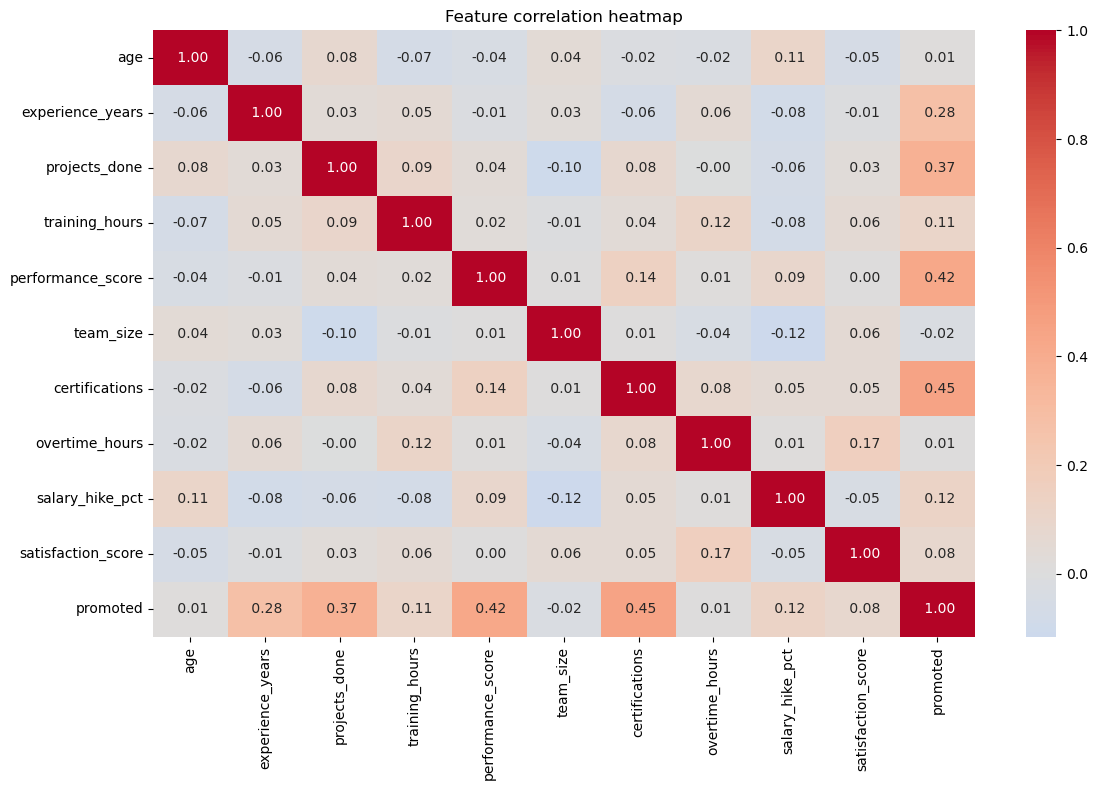

In [13]:
# correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),
                annot=True,
                fmt=" .2f",
                cmap="coolwarm",
                center= 0)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

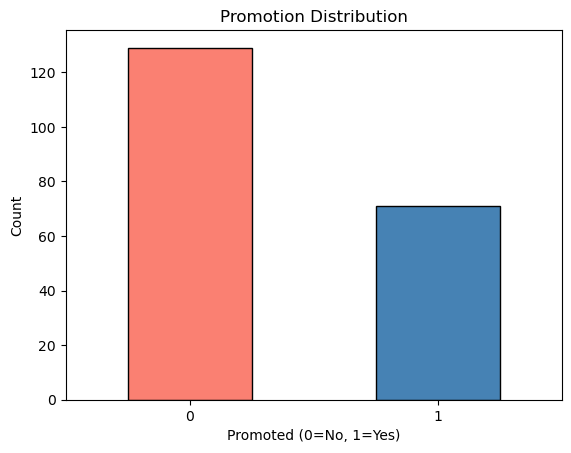

In [21]:
# distribution of promoted vs not promoted 
plt.Figure(figsize= (6,4))
df["promoted"].value_counts().plot(
                kind="bar",
                color=["salmon","steelblue"],
                edgecolor="black"
)
plt.title("Promotion Distribution")
plt.xlabel("Promoted (0=No, 1=Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [31]:

# model building

X= df.drop("promoted",axis=1)
y=df["promoted"]


print("features :", list(X.columns))
print("X shape :", X.shape)


# split
X_train, X_test, y_train, y_test = train_test_split(
                        X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)


model = GaussianNB(
    var_smoothing=1e-9 # smoothing parameter 
)

model.fit(X_train_scaled,y_train)
y_pred= model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

# check overfitting 

train_acc= accuracy_score(y_train,model.predict(X_train_scaled))
test_acc= accuracy_score(y_test,y_pred)



print("\nTrain acc:", round(train_acc,4))
print("\nTest acc:", round(test_acc,4))
print("\ndiffernce:", round(train_acc-test_acc,4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

features : ['age', 'experience_years', 'projects_done', 'training_hours', 'performance_score', 'team_size', 'certifications', 'overtime_hours', 'salary_hike_pct', 'satisfaction_score']
X shape : (200, 10)

Train acc: 0.8875

Test acc: 0.875

differnce: 0.0125

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91        25
           1       0.92      0.73      0.81        15

    accuracy                           0.88        40
   macro avg       0.89      0.85      0.86        40
weighted avg       0.88      0.88      0.87        40

